In [1]:
# Load Data
import numpy as np

container = np.load('split_data.npz')

# Access data
X_train = container['X_train']
y_train = container['y_train']

# Access data
X_test = container['X_test']
y_test = container['y_test']

In [7]:
# Previously I've considered the adaptative Kernel KNN, which I now changed to fixed bandwidth
from kernel_models import KernelKNNAdaptative, SmoothKernels
from sklearn.metrics import r2_score

result_list = []

for k in range(1,21):
    # Cosine kernel
    model = KernelKNNAdaptative(k=k, kernel=SmoothKernels.cosine)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_train)
    
    score = r2_score(y_train, y_pred)

    params = {'k': k, 'kernel': 'Cosine'} 
    result = {'score': score, 'params': params}
    result_list.append(result)
    
    # Epanechnikov kernel
    model = KernelKNNAdaptative(k=k, kernel=SmoothKernels.epanechnikov)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_train)
    
    score = r2_score(y_train, y_pred)

    params = {'k': k, 'kernel': 'Epanechnikov'} 
    result = {'score': score, 'params': params}
    result_list.append(result)

    # Exponential kernel
    model = KernelKNNAdaptative(k=k, kernel=SmoothKernels.exponential)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_train)
    
    score = r2_score(y_train, y_pred)

    params = {'k': k, 'kernel': 'Exponential'} 
    result = {'score': score, 'params': params}
    result_list.append(result)

    # Gaussian kernel
    model = KernelKNNAdaptative(k=k, kernel=SmoothKernels.gaussian)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_train)
    
    score = r2_score(y_train, y_pred)

    params = {'k': k, 'kernel': 'Gaussian'} 
    result = {'score': score, 'params': params}
    result_list.append(result)

    # Triangular kernel
    model = KernelKNNAdaptative(k=k, kernel=SmoothKernels.triangular)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_train)
    
    score = r2_score(y_train, y_pred)

    params = {'k': k, 'kernel': 'Triangular'} 
    result = {'score': score, 'params': params}
    result_list.append(result)

    # Uniform kernel
    model = KernelKNNAdaptative(k=k, kernel=SmoothKernels.uniform)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_train)
    
    score = r2_score(y_train, y_pred)

    params = {'k': k, 'kernel': 'Uniform'} 
    result = {'score': score, 'params': params}
    result_list.append(result)

best_result = max(result_list, key=lambda x: x['score'])

print(f"Max Score: {best_result['score']}")
print(f"Best Params: {best_result['params']}")

Max Score: 0.9201179453681274
Best Params: {'k': 13, 'kernel': 'Triangular'}


In [8]:
result_list.sort(key=lambda x: x['score'], reverse=True)
result_list[:10]

[{'score': 0.9201179453681274, 'params': {'k': 13, 'kernel': 'Triangular'}},
 {'score': 0.9199189542751041, 'params': {'k': 14, 'kernel': 'Triangular'}},
 {'score': 0.9198310573239445, 'params': {'k': 12, 'kernel': 'Triangular'}},
 {'score': 0.9197360765762341, 'params': {'k': 11, 'kernel': 'Triangular'}},
 {'score': 0.9196617139260119, 'params': {'k': 10, 'kernel': 'Triangular'}},
 {'score': 0.919636427380507, 'params': {'k': 15, 'kernel': 'Triangular'}},
 {'score': 0.9195943718402121, 'params': {'k': 9, 'kernel': 'Triangular'}},
 {'score': 0.9195177930666528, 'params': {'k': 13, 'kernel': 'Cosine'}},
 {'score': 0.9194404334163887, 'params': {'k': 10, 'kernel': 'Cosine'}},
 {'score': 0.9194070793046445, 'params': {'k': 9, 'kernel': 'Cosine'}}]

In [11]:
from kernel_models import KernelKNNAdaptative, SmoothKernels
from sklearn.metrics import r2_score

model = KernelKNNAdaptative(k=13, kernel=SmoothKernels.triangular)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(r2_score(y_test, y_pred))

0.91224136129308


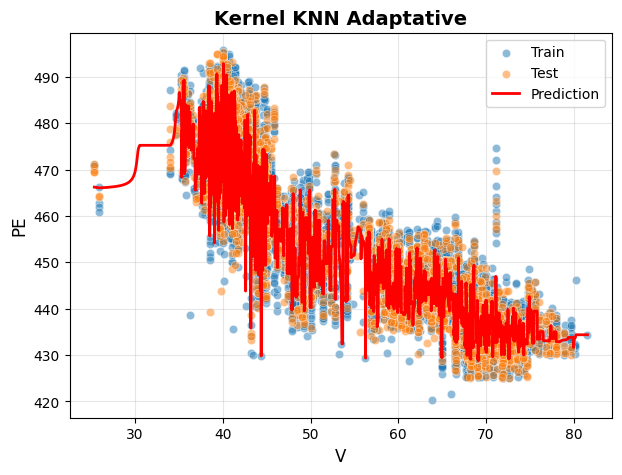

In [12]:
from utils import plot_predictions

step = 0.01
X_min = min(X_train.min(), X_test.min())
X_max = max(X_train.max(), X_test.max())
X_line = np.arange(X_min, X_max + step, step).reshape(-1, 1)
y_line = model.predict(X_line)

plot_predictions(X_line, y_line, X_train, y_train, X_test, y_test, title='Kernel KNN Adaptative', name='Images/kernel_knn_adapt.png')